# Gesture Detection – Triple Stream Pipeline

In [1]:
import os
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

BASE_PATH = '/kaggle/input/datasets/mgriffe2004/dataclassifier/Hand Gesture Accelerometer and Gyroscope Dataset (HGAG-DATA)/HGAG-DATA'

# Tên folder trong HGAG-DATA1 phải khớp chính xác
SELECTED_GESTURES = [
    'Clapping',
    'Fist Making',
    'Thumb Up',  # tên folder trong dataset
]

WINDOW_SIZE = 160
OVERLAP     = 80

# ===== Luồng A – HPF 5Hz =====
HPF_A_CUTOFF_HZ  = 2.0
ACCEL_DEADBAND_A = 0.08
GYRO_DEADBAND_A  = 0.04

# ===== Luồng B – HPF 0.5Hz 
HPF_B_CUTOFF_HZ  = 0.3
ACCEL_DEADBAND_B = 0.0
GYRO_DEADBAND_B  = 0.0

# ===== Luồng C – RAW =====
RAW_SAMPLE_RATE    = 200
TARGET_SAMPLE_RATE = 100

FEATURES_PER_AXIS  = 15
NUM_AXES           = 6
NUM_STREAMS        = 3
NUM_FEATURES_TOTAL = FEATURES_PER_AXIS * NUM_AXES * NUM_STREAMS  # 270

XGB_N_ESTIMATORS  = 40
XGB_MAX_DEPTH     = 3
XGB_LEARNING_RATE = 0.08

print('Config OK')
print(f'Luồng A : HPF {HPF_A_CUTOFF_HZ}Hz | deadband accel={ACCEL_DEADBAND_A} gyro={GYRO_DEADBAND_A}')
print(f'Luồng B : HPF {HPF_B_CUTOFF_HZ}Hz | deadband = 0  ← hạ xuống để bắt Thumbs Up ~0.6Hz')
print(f'Luồng C : RAW – giữ gravity/DC component')
print(f'Total features: {NUM_FEATURES_TOTAL}  (90 x 3 streams)')


Config OK
Luồng A : HPF 2.0Hz | deadband accel=0.08 gyro=0.04
Luồng B : HPF 0.3Hz | deadband = 0  ← hạ xuống để bắt Thumbs Up ~0.6Hz
Luồng C : RAW – giữ gravity/DC component
Total features: 270  (90 x 3 streams)


## Load Data

In [2]:
import pandas as pd
import numpy as np
import os
import glob

AXES = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']

def load_gesture_data(base_path, gesture_name):
    all_data = []
    gesture_path = os.path.join(base_path, 'HGAG-DATA1', gesture_name)
    if not os.path.exists(gesture_path):
        print(f'  Không tìm thấy: {gesture_path}')
        return None
    for subject in sorted(os.listdir(gesture_path)):
        subject_path = os.path.join(gesture_path, subject)
        if not os.path.isdir(subject_path):
            continue
        subfolders = os.listdir(subject_path)
        csv_folder = [f for f in subfolders if 'csv' in f.lower()]
        if not csv_folder:
            continue
        csv_path  = os.path.join(subject_path, csv_folder[0])
        axis_data = []
        for axis in AXES:
            files = glob.glob(os.path.join(csv_path, f'*{axis}*'))
            if files:
                df = pd.read_csv(files[0], header=None)
                axis_data.append(df.values.flatten())
        if len(axis_data) == 6:
            min_len = min(len(a) for a in axis_data)
            matrix  = np.column_stack([a[:min_len] for a in axis_data])
            all_data.append(matrix)
    if all_data:
        combined = np.vstack(all_data)
        print(f'  {gesture_name}: {combined.shape}')
        return combined
    print(f'  Không có data: {gesture_name}')
    return None

gesture_data = {}
for gesture in SELECTED_GESTURES:
    data = load_gesture_data(BASE_PATH, gesture)
    if data is not None:
        gesture_data[gesture] = data

print(f'\nLoaded {len(gesture_data)}/{len(SELECTED_GESTURES)} gestures')

  Clapping: (537500, 6)
  Fist Making: (537000, 6)
  Thumb Up: (537500, 6)

Loaded 3/3 gestures


## Preprocessing – Triple Stream

In [3]:
#IIR high-pass bậc 1 , dạng rời rạc : y = alpha * (prev_output + x - prev_input)
def high_pass_filter(data, cutoff_hz, fs=200.0):
    dt    = 1.0 / fs
    rc    = 1.0 / (2.0 * np.pi * cutoff_hz)
    alpha = rc / (rc + dt)
    out          = np.zeros_like(data, dtype=np.float32)
    prev_input   = data[0].astype(np.float32).copy()
    prev_output  = np.zeros(data.shape[1], dtype=np.float32)
    for i in range(1, len(data)):
        x = data[i].astype(np.float32)
        y = alpha * (prev_output + x - prev_input)
        out[i]      = y
        prev_input  = x
        prev_output = y
    return out

def apply_deadband(data, accel_db, gyro_db):
    if accel_db == 0.0 and gyro_db == 0.0:
        return data.copy().astype(np.float32)
    out = data.copy().astype(np.float32)
    for axis in range(out.shape[1]):
        db = accel_db if axis < 3 else gyro_db
        out[:, axis] = np.where(np.abs(out[:, axis]) < db, 0.0, out[:, axis])
    return out

def resample_200_to_100hz(data):
    return data[::2]

def normalize_gravity(data):
    """
    Chuẩn hóa luồng C: trừ mean toàn đoạn cho accel (ax,ay,az)
    để giữ lại *biến đổi tư thế* thay vì giá trị DC tuyệt đối.
    Gyro (gx,gy,gz) giữ nguyên.
    """
    out = data.copy().astype(np.float32)
    # Chỉ trừ mean cho 3 accel axes
    out[:, :3] -= out[:, :3].mean(axis=0)
    return out

def preprocess_triple(data_200hz):
    """
    Trả về (proc_A, proc_B, proc_C) @ 100Hz
    A: HPF 5Hz + deadband
    B: HPF 0.5Hz, không deadband  ← bắt motion Thumbs Up ~0.6Hz
    C: RAW normalize gravity       ← giữ delta tư thế, bỏ DC offset
    """
    # Bỏ 20 sample đầu (warm-up HPF, đặc biệt HPF B 0.5Hz cần ~0.5/0.5=1s)
    WARMUP = 40  # 40 sample @ 200Hz = 0.2s
    raw = data_200hz[WARMUP:].astype(np.float32)

    # Luồng A
    fA = high_pass_filter(raw, HPF_A_CUTOFF_HZ, RAW_SAMPLE_RATE)
    fA = apply_deadband(fA, ACCEL_DEADBAND_A, GYRO_DEADBAND_A)
    pA = resample_200_to_100hz(fA)

    # Luồng B – HPF 0.5Hz
    fB = high_pass_filter(raw, HPF_B_CUTOFF_HZ, RAW_SAMPLE_RATE)
    pB = resample_200_to_100hz(fB)

    # Luồng C – normalize gravity thay vì RAW thuần
    pC = resample_200_to_100hz(normalize_gravity(raw))

    return pA, pB, pC


# Preprocess tất cả gestures
gesture_data_A = {}
gesture_data_B = {}
gesture_data_C = {}

for gesture, data in gesture_data.items():
    pA, pB, pC = preprocess_triple(data)
    gesture_data_A[gesture] = pA
    gesture_data_B[gesture] = pB
    gesture_data_C[gesture] = pC
    print(f'{gesture}: A={pA.shape} | B={pB.shape} | C={pC.shape}')

# Verify: luồng C mean ax phải gần 0 (đã trừ mean), nhưng std khác nhau giữa gestures
print('\n=== Verify luồng C – mean ax (phải ≈ 0 sau normalize) ===')
for g in SELECTED_GESTURES:
    if g in gesture_data_C:
        print(f'  {g}: ax_mean={gesture_data_C[g][:, 0].mean():.4f}  ax_std={gesture_data_C[g][:, 0].std():.4f}')


Clapping: A=(268730, 6) | B=(268730, 6) | C=(268730, 6)
Fist Making: A=(268480, 6) | B=(268480, 6) | C=(268480, 6)
Thumb Up: A=(268730, 6) | B=(268730, 6) | C=(268730, 6)

=== Verify luồng C – mean ax (phải ≈ 0 sau normalize) ===
  Clapping: ax_mean=-0.0107  ax_std=1.5080
  Fist Making: ax_mean=-0.0086  ax_std=0.7112
  Thumb Up: ax_mean=-0.0077  ax_std=0.6728


## Feature Extraction – Triple Stream

- indices   0– 89: luồng A (HPF 5Hz)
- indices  90–179: luồng B (HPF 1.5Hz)
- indices 180–269: luồng C (RAW – gravity)

In [4]:
from scipy.fft import fft

def extract_features_single(window):
    """window: (WINDOW_SIZE, 6) → 90 features (15 per axis)"""
    features = []
    for axis in window.T:
        axis = axis.astype(np.float32)
        sorted_axis = np.sort(axis)
        fft_mag = np.abs(fft(axis))

        features += [
            float(np.mean(axis)),                          # 0  mean
            float(np.std(axis)),                           # 1  std
            float(np.min(axis)),                           # 2  min
            float(np.max(axis)),                           # 3  max
            float(np.max(axis) - np.min(axis)),            # 4  range
            float(np.mean(np.abs(axis))),                  # 5  mean_abs
            float(np.sum(np.abs(np.diff(axis)))),          # 6  total_variation : đo độ gồ gề của tín hiệu  
            float(np.percentile(sorted_axis, 25)),         # 7  q25
            float(np.percentile(sorted_axis, 75)),         # 8  q75
            float(np.sqrt(np.mean(axis**2))),              # 9  rms : năng lượng tín hiệu
            float(fft_mag[1]),                             # 10 fft bin1 => lấy parttern tần số riêng  
            float(fft_mag[2]),                             # 11 fft bin2
            float(fft_mag[3]),                             # 12 fft bin3
            float(fft_mag[4]),                             # 13 fft bin4
            float(fft_mag[5]),                             # 14 fft bin5
        ]
    return features  # 90 dims (15 x 6)


def extract_features_triple(window_A, window_B, window_C):
    """→ 270 features = concat(A, B, C)"""
    return (extract_features_single(window_A) +
            extract_features_single(window_B) +
            extract_features_single(window_C))


def create_windows_triple(dA, dB, dC, window_size, overlap, label):
    step = window_size - overlap
    X, y = [], []
    n = min(len(dA), len(dB), len(dC))
    for start in range(0, n - window_size + 1, step):
        wA = dA[start:start + window_size]
        wB = dB[start:start + window_size]
        wC = dC[start:start + window_size]
        X.append(extract_features_triple(wA, wB, wC))
        y.append(label)
    return X, y


# Tạo dataset
all_X, all_y = [], []

for gesture in SELECTED_GESTURES:
    if gesture not in gesture_data_A:
        continue
    X_g, y_g = create_windows_triple(
        gesture_data_A[gesture],
        gesture_data_B[gesture],
        gesture_data_C[gesture],
        WINDOW_SIZE, OVERLAP, gesture
    )
    all_X.extend(X_g)
    all_y.extend(y_g)
    print(f'{gesture}: {len(X_g)} windows')

X = np.array(all_X)
y = np.array(all_y)

print(f'\nTổng: X={X.shape}, y={y.shape}')
print(f'Feature: {X.shape[1]}  (90xA + 90xB + 90xC)')
assert X.shape[1] == 270, f'Feature count sai: {X.shape[1]}'


Clapping: 3358 windows
Fist Making: 3355 windows
Thumb Up: 3358 windows

Tổng: X=(10071, 270), y=(10071,)
Feature: 270  (90xA + 90xB + 90xC)


## Encode + Split + Scale

In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f'Classes: {le.classes_}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=SEED, stratify=y_encoded
)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Scaler mean shape: {scaler.mean_.shape}')  # phải là (270,)

Classes: ['Clapping' 'Fist Making' 'Thumb Up']
Train: 8056 | Test: 2015
Scaler mean shape: (270,)


## Train XGBoost


=== Classification Report – Triple Stream Base Model ===
              precision    recall  f1-score   support

    Clapping       0.98      0.95      0.96       672
 Fist Making       0.98      0.97      0.98       671
    Thumb Up       0.95      0.97      0.96       672

    accuracy                           0.97      2015
   macro avg       0.97      0.97      0.97      2015
weighted avg       0.97      0.97      0.97      2015



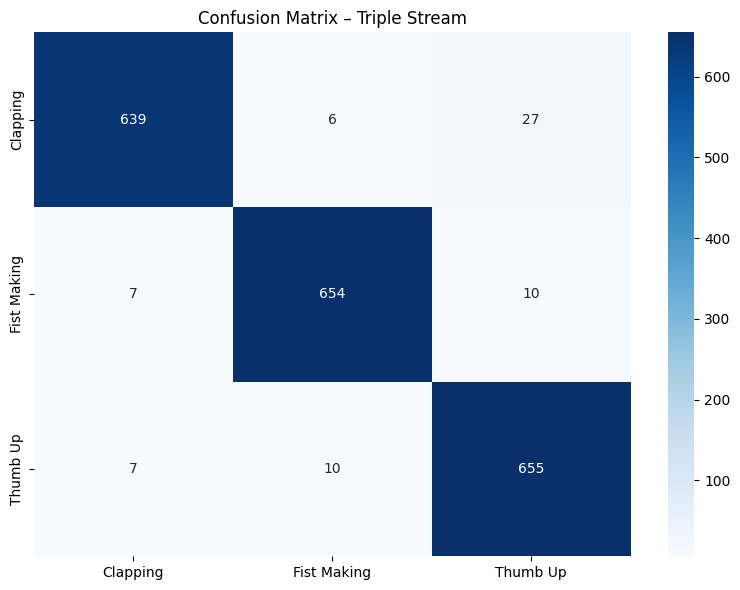

In [6]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model = XGBClassifier(
    n_estimators     = XGB_N_ESTIMATORS,
    max_depth        = XGB_MAX_DEPTH,
    learning_rate    = XGB_LEARNING_RATE,
    subsample        = 0.9,
    colsample_bytree = 0.9,
    reg_lambda       = 1.0,
    eval_metric      = 'mlogloss',
    random_state     = SEED
)

model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=False
)

y_pred = model.predict(X_test_scaled)
print('\n=== Classification Report – Triple Stream Base Model ===')
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix – Triple Stream')
plt.tight_layout()
plt.show()

## Lưu Base Model

In [7]:
import pickle

model_bundle = {
    'model'            : model,
    'scaler'           : scaler,
    'label_encoder'    : le,
    'gestures'         : list(le.classes_),
    'window_size'      : WINDOW_SIZE,
    'overlap'          : OVERLAP,
    'sampling_rate'    : TARGET_SAMPLE_RATE,
    'hpf_a_cutoff_hz'  : HPF_A_CUTOFF_HZ,
    'accel_deadband_a' : ACCEL_DEADBAND_A,
    'gyro_deadband_a'  : GYRO_DEADBAND_A,
    'hpf_b_cutoff_hz'  : HPF_B_CUTOFF_HZ,
    'num_features'     : NUM_FEATURES_TOTAL,
    'num_streams'      : NUM_STREAMS,
}

with open('/kaggle/working/gesture_model_triple.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)
print('Saved: gesture_model_triple.pkl')
print(f'Features: {NUM_FEATURES_TOTAL}')

Saved: gesture_model_triple.pkl
Features: 270


## Export Scaler → Arduino

In [8]:
def print_c_array(name, values, per_row=6):
    print(f'const float {name}[NUM_FEATURES] = {{')
    for i in range(0, len(values), per_row):
        chunk = values[i:i+per_row]
        print('    ' + ', '.join(f'{v:.8f}f' for v in chunk) + ',')
    print('};\n')

print('// ===== PASTE VÀO sketch .ino =====')
print(f'// NUM_FEATURES = {len(scaler.mean_)}')
print(f'// indices   0– 89: luồng A (HPF 5Hz)')
print(f'// indices  90–179: luồng B (HPF 1.5Hz)')
print(f'// indices 180–269: luồng C (RAW)\n')
print_c_array('FEATURE_MEAN',  scaler.mean_)
print_c_array('FEATURE_SCALE', scaler.scale_)

// ===== PASTE VÀO sketch .ino =====
// NUM_FEATURES = 270
// indices   0– 89: luồng A (HPF 5Hz)
// indices  90–179: luồng B (HPF 1.5Hz)
// indices 180–269: luồng C (RAW)

const float FEATURE_MEAN[NUM_FEATURES] = {
    -0.00630524f, 0.84377591f, -3.89463243f, 3.61798066f, 7.51261310f, 0.39297763f,
    104.38681443f, -0.11268998f, 0.01292176f, 0.84383251f, 1.20300363f, 0.97826604f,
    1.07440401f, 1.23923022f, 1.25386699f, 0.00456460f, 1.40020359f, -6.37104193f,
    5.05776058f, 11.42880251f, 0.66480526f, 177.91887032f, -0.05880951f, 0.15351358f,
    1.40026028f, 1.51984100f, 1.29713082f, 1.40183460f, 1.57455635f, 1.60589479f,
    0.02194906f, 1.73216696f, -10.96015112f, 6.93418225f, 17.89433336f, 0.71389618f,
    185.77195982f, -0.02772374f, 0.18517827f, 1.73241892f, 3.43209266f, 2.54241077f,
    2.86136395f, 3.31322852f, 3.19045738f, 0.00000335f, 0.38031623f, -1.60582185f,
    1.90630180f, 3.51212365f, 0.14138738f, 38.57753477f, -0.00499979f, 0.00226163f,
    0.38032447f, 0.25903972f

## Fine-tune với data mới

In [9]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

BASE_FINETUNE = '/kaggle/input/datasets/mgriffe2004/dataset-finetune1'
AXES_NEW = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
LABEL_MAP = {
    'clapping_clean.csv'    : 'Clapping',
    'fist_making_clean.csv' : 'Fist Making',
    'thumbs_up_clean.csv'   : 'Thumbs Up',
}

def load_new_csv(csv_path, axes):
    df = pd.read_csv(csv_path)
    missing = [c for c in axes if c not in df.columns]
    if missing:
        raise ValueError(f'Thiếu cột {missing} trong {csv_path}')
    return df[axes].values

all_X_new, all_y_new = [], []

for csv_file, gesture_label in LABEL_MAP.items():
    csv_path = os.path.join(BASE_FINETUNE, csv_file)
    if not os.path.exists(csv_path):
        print(f'Không tìm thấy: {csv_path} – bỏ qua')
        continue
    raw_data = load_new_csv(csv_path, AXES_NEW)
    dA, dB, dC = preprocess_triple(raw_data)
    X_g, y_g = create_windows_triple(dA, dB, dC, WINDOW_SIZE, OVERLAP, gesture_label)
    all_X_new.extend(X_g)
    all_y_new.extend(y_g)
    print(f'{gesture_label:30s} | windows: {len(X_g)}')

X_new        = np.array(all_X_new)
y_new        = np.array(all_y_new)
X_new_scaled = scaler.transform(X_new)

# Verify nhãn khớp với le.classes_ trước khi encode
print("\nle.classes_ =", le.classes_)
print("unique y_new =", np.unique(y_new))
y_new = np.array(all_y_new)
y_new = np.where(y_new == "Thumbs Up", "Thumb Up", y_new)

print("le.classes_ =", le.classes_)
print("unique y_new =", np.unique(y_new))

y_new_encoded = le.transform(y_new)
print(f'\nTổng data mới: X={X_new.shape}')


Clapping                       | windows: 109
Fist Making                    | windows: 110
Thumbs Up                      | windows: 109

le.classes_ = ['Clapping' 'Fist Making' 'Thumb Up']
unique y_new = ['Clapping' 'Fist Making' 'Thumbs Up']
le.classes_ = ['Clapping' 'Fist Making' 'Thumb Up']
unique y_new = ['Clapping' 'Fist Making' 'Thumb Up']

Tổng data mới: X=(328, 270)


In [10]:
X_ft_train, X_ft_temp, y_ft_train, y_ft_temp = train_test_split(
    X_new_scaled, y_new_encoded, test_size=0.30, random_state=SEED, stratify=y_new_encoded
)
X_ft_val, X_ft_test, y_ft_val, y_ft_test = train_test_split(
    X_ft_temp, y_ft_temp, test_size=0.50, random_state=SEED, stratify=y_ft_temp
)

dtrain_new = xgb.DMatrix(X_ft_train, label=y_ft_train)
dval_new   = xgb.DMatrix(X_ft_val,   label=y_ft_val)
dtest_new  = xgb.DMatrix(X_ft_test,  label=y_ft_test)

params = model.get_xgb_params()
params['num_class']   = len(le.classes_)
params['eval_metric'] = 'mlogloss'

booster_finetuned = xgb.train(
    params              = params,
    dtrain              = dtrain_new,
    num_boost_round     = 12,
    xgb_model           = model.get_booster(),
    evals               = [(dtrain_new, 'train'), (dval_new, 'val')],
    verbose_eval        = 5,
    early_stopping_rounds = 5
)
print(f'Fine-tune xong! Rounds: {booster_finetuned.num_boosted_rounds()}')

[0]	train-mlogloss:1.21658	val-mlogloss:1.20656
[5]	train-mlogloss:0.62769	val-mlogloss:0.65395
[10]	train-mlogloss:0.38131	val-mlogloss:0.41966
[11]	train-mlogloss:0.34758	val-mlogloss:0.38789
Fine-tune xong! Rounds: 52


## Đánh giá sau Fine-tune

=== Fine-tune VAL ===
              precision    recall  f1-score   support

    Clapping       0.94      1.00      0.97        17
 Fist Making       1.00      1.00      1.00        16
    Thumb Up       1.00      0.94      0.97        16

    accuracy                           0.98        49
   macro avg       0.98      0.98      0.98        49
weighted avg       0.98      0.98      0.98        49



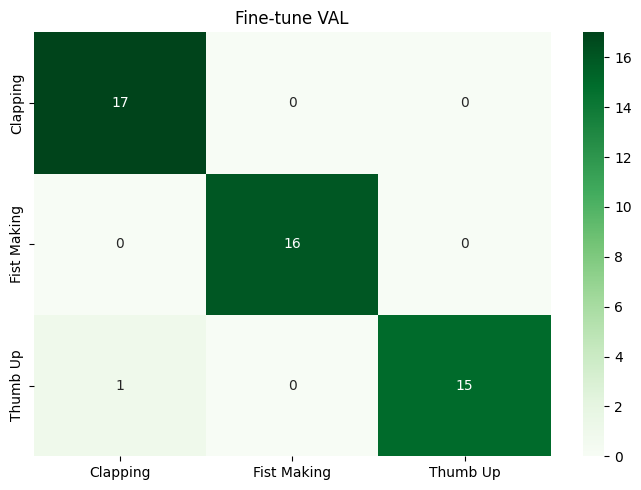

=== Fine-tune TEST ===
              precision    recall  f1-score   support

    Clapping       1.00      1.00      1.00        16
 Fist Making       1.00      1.00      1.00        17
    Thumb Up       1.00      1.00      1.00        17

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



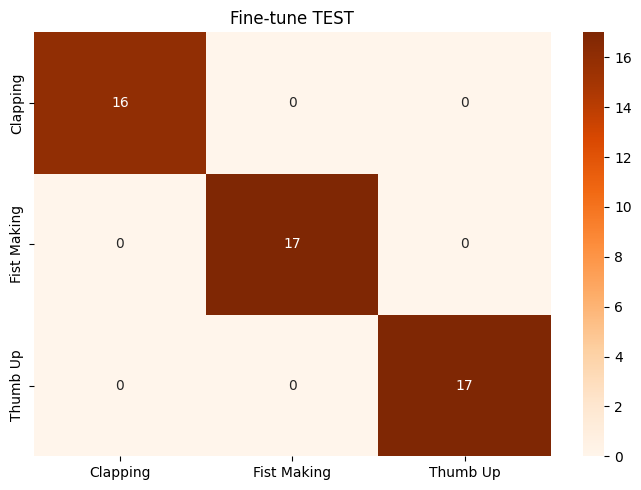

=== Base TEST after Fine-tune ===
              precision    recall  f1-score   support

    Clapping       0.96      0.96      0.96       672
 Fist Making       0.92      0.99      0.95       671
    Thumb Up       0.97      0.90      0.93       672

    accuracy                           0.95      2015
   macro avg       0.95      0.95      0.95      2015
weighted avg       0.95      0.95      0.95      2015



In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def booster_predict_classes(booster, dmatrix):
    pred_raw = booster.predict(dmatrix)
    if pred_raw.ndim == 2:
        return np.argmax(pred_raw, axis=1).astype(int)
    return pred_raw.astype(int)

# Val
y_val_pred = booster_predict_classes(booster_finetuned, dval_new)
print('=== Fine-tune VAL ===')
print(classification_report(y_ft_val, y_val_pred, target_names=le.classes_))
cm = confusion_matrix(y_ft_val, y_val_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Fine-tune VAL')
plt.tight_layout()
plt.show()

# Test
y_test_pred = booster_predict_classes(booster_finetuned, dtest_new)
print('=== Fine-tune TEST ===')
print(classification_report(y_ft_test, y_test_pred, target_names=le.classes_))
cm = confusion_matrix(y_ft_test, y_test_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Fine-tune TEST')
plt.tight_layout()
plt.show()

# Base test – check catastrophic forgetting
dbase = xgb.DMatrix(X_test_scaled, label=y_test)
y_base_after = booster_predict_classes(booster_finetuned, dbase)
print('=== Base TEST after Fine-tune ===')
print(classification_report(y_test, y_base_after, target_names=le.classes_))

## Lưu Bundle Fine-tuned

In [12]:
import pickle

model._Booster = booster_finetuned

bundle_finetuned = {
    'model'            : model,
    'scaler'           : scaler,
    'label_encoder'    : le,
    'gestures'         : list(le.classes_),
    'window_size'      : WINDOW_SIZE,
    'overlap'          : OVERLAP,
    'sampling_rate'    : TARGET_SAMPLE_RATE,
    'hpf_a_cutoff_hz'  : HPF_A_CUTOFF_HZ,
    'accel_deadband_a' : ACCEL_DEADBAND_A,
    'gyro_deadband_a'  : GYRO_DEADBAND_A,
    'hpf_b_cutoff_hz'  : HPF_B_CUTOFF_HZ,
    'num_features'     : NUM_FEATURES_TOTAL,
    'num_streams'      : NUM_STREAMS,
}

with open('/kaggle/working/gesture_model_triple_finetuned.pkl', 'wb') as f:
    pickle.dump(bundle_finetuned, f)
print('Saved: gesture_model_triple_finetuned.pkl')
print(f'Trees: {booster_finetuned.num_boosted_rounds()}')

Saved: gesture_model_triple_finetuned.pkl
Trees: 52


## Export model → gesture_model-1.h

In [13]:
!pip install micromlgen

  Preparing metadata (setup.py) ... done
  Created wheel for micromlgen: filename=micromlgen-1.1.28-py3-none-any.whl size=32152 sha256=48b70606676293b50c49bbadd7f8b60192db0e834f980fa7650ac17f7ffa7a6f
  Stored in directory: /root/.cache/pip/wheels/16/02/8a/3a8b533174e4f7691a8fd72dab4493fb6819b79f8fcc1d18a6
Successfully built micromlgen


In [14]:
from micromlgen import port

model._Booster = booster_finetuned
c_code = port(model, classmap={i: name for i, name in enumerate(le.classes_)})

with open('/kaggle/working/gesture_model-1.h', 'w') as f:
    f.write(c_code)

print('Exported: gesture_model-1.h')
print('\n--- 5 dòng đầu (verify feature count) ---')
print('\n'.join(c_code.split('\n')[:5]))

Exported: gesture_model-1.h

--- 5 dòng đầu (verify feature count) ---
#pragma once
#include <cstdarg>
namespace Eloquent {
    namespace ML {
        namespace Port {


## Test Inference

In [15]:
def predict_gesture(raw_200hz, bundle):
    pA, pB, pC = preprocess_triple(raw_200hz)
    wA, wB, wC = pA[:WINDOW_SIZE], pB[:WINDOW_SIZE], pC[:WINDOW_SIZE]
    features        = np.array(extract_features_triple(wA, wB, wC)).reshape(1, -1)
    features_scaled = bundle['scaler'].transform(features)
    dtest    = xgb.DMatrix(features_scaled)
    pred_raw = bundle['model'].get_booster().predict(dtest)
    if pred_raw.ndim == 2:
        pred_class = int(np.argmax(pred_raw[0]))
        confidence = float(np.max(pred_raw[0]) * 100)
    else:
        pred_class = int(pred_raw[0])
        confidence = 100.0
    return bundle['label_encoder'].inverse_transform([pred_class])[0], confidence

print('=== Smoke Test ===')
for gesture in SELECTED_GESTURES:
    raw = gesture_data[gesture][:200]
    pred, conf = predict_gesture(raw, bundle_finetuned)
    status = '✅' if pred == gesture else '❌'
    print(f'{status} {gesture:30s} → {pred} ({conf:.1f}%)')

=== Smoke Test ===
✅ Clapping                       → Clapping (91.8%)
✅ Fist Making                    → Fist Making (98.3%)
✅ Thumb Up                       → Thumb Up (70.8%)


In [16]:
from scipy.signal import welch
import numpy as np

def band_energy(signal, fs=200):

    signal = signal - np.mean(signal)

    freqs, psd = welch(signal, fs=fs, nperseg=512)

    low = psd[(freqs>=0.1) & (freqs<1)].sum()
    mid = psd[(freqs>=1) & (freqs<3)].sum()
    high = psd[(freqs>=3) & (freqs<8)].sum()

    return low, mid, high


for gesture, data in gesture_data.items():

    accel = data[:,:3]
    gyro  = data[:,3:6]

    a_mag = np.sqrt((accel**2).sum(axis=1))
    g_mag = np.sqrt((gyro**2).sum(axis=1))

    la, ma, ha = band_energy(a_mag)
    lg, mg, hg = band_energy(g_mag)

    print(gesture)
    print(" accel energy:", la, ma, ha)
    print(" gyro  energy:", lg, mg, hg)
    print()

Clapping
 accel energy: 5.566827154528248 4.925175609425819 3.347951156095899
 gyro  energy: 0.21235429161665892 0.26087361370479917 0.052354293003081774

Fist Making
 accel energy: 2.2877472578567537 1.9905122077327757 0.8211565908904355
 gyro  energy: 0.011829506731123037 0.018171805945597343 0.0072152044041502

Thumb Up
 accel energy: 2.2375155044169754 1.7910840014011684 0.7357609074465332
 gyro  energy: 0.1263783172258003 0.19325687252130505 0.05542325079231951

